In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *

In [2]:
#신경망 구성에 필요한 라이브러리 임포트
import torch
from torch import nn
from torch.optim import Adam        #optimizer -> 최적화

#파이토치에서 데이터를 다룰때 사용하는 도구들
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# 디바이스 준비 (GPU, CPU)
# 파이토치 설치 : GPU 버전으로 설치 -> GPU도 사용할 수 있고, CPU 도 사용할 수 있다
# CPU버전으로 설치하면 CPU만 사용하게 된다. '
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)


cuda


In [4]:
# 데이터 전처리 1
# 데이터 불러오기
path = 'https://bit.ly/advertising_csv'
adv = pd.read_csv(path)


# x, y 분할
target = 'Sales'
x = adv.drop(target, axis=1)
y = adv.loc[:, target]


# 학습/검증 데이터 분리
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=20)
print(type(x_train), type(x_val))


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
print(type(x_train), type(x_val))


<class 'pandas.DataFrame'> <class 'pandas.DataFrame'>
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [5]:
# 데이터 전처리 2
# 텐서 변환
x_train_ts = torch.tensor(x_train, dtype=torch.float32)

#y_train 자체는 series => 이건 바로 tensor 변환이 안된다. 따라서 series의 values를 가져와서 tensor로 변환해야 한다.
y_train_ts = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
x_val_ts = torch.tensor(x_val, dtype=torch.float32)
y_val_ts = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# 디바이스 할당
#to (이동할 장치 지정)
#to 메소드: 데이터 이동

# x_train_ts 오브젝트(tensor objec t) 안에 있는 method  즉 tensor 로 안 바꾸면 to method 바꿀수없다
#device = 'cuda'
x_train_ts, y_train_ts = x_train_ts.to(device), y_train_ts.to(device)
x_val_ts, y_val_ts = x_val_ts.to(device), y_val_ts.to(device)


In [6]:
#학습에 사용할 텐서데이터셋 생성
BATCH_SIZE = 32
train_ds = TensorDataset(x_train_ts, y_train_ts)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [16]:
#신경망 모델 생성
in_features = x_train_ts.shape[1]

#1.2
model = nn.Sequential(
    nn.Linear(in_features, 1)
    ).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [17]:
# 학습 진행
EPOCHS = 100
tr_loss_list, val_loss_list = [], []


# 1. 학습 데이터 반복 학습
for epoch in range(EPOCHS):
    model.train() # 모델 학습 모드
    total_loss = 0.0
    n_batch = 0


    # 2. 에포크마다 배치 단위 학습
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)


        # 3. 학습
        # 오차 순전파: 학습 데이터에서 오차 계산
        pred = model(x) # 모델에 x를 입력해 예측
        loss = loss_fn(pred, y) # 오차 계산


        # 오차 역전파: 오차로부터 가중치 업데이트
        optimizer.zero_grad() # 기울기(gradient) 초기화
        loss.backward() # 손실 함수를 기준으로 각 가중치의 기울기를 계산
        optimizer.step() # 기울기를 기준으로 가중치 조정


        total_loss += loss.item()
        n_batch += 1


    # 에포크마다 학습 오차 집계
    tr_loss = total_loss / n_batch


    # 4. 검증
    model.eval() # 모델 평가/추론 모드
    with torch.no_grad():
        val_pred = model(x_val_ts)
        val_loss = loss_fn(val_pred, y_val_ts) #현재 GPU에 저장되어있는


    tr_loss_list.append(tr_loss) #RAM
    val_loss_list.append(val_loss.item())  #현재 CPU에 저장되어있는 것들이 .item() 을 통해 GPU로 이동   VRAM
    print(f'Epoch {epoch+1 : 4d} | train loss {tr_loss:.4f} | val loss {val_loss:.4f}')


Epoch    1 | train loss 218.5480 | val loss 227.0793
Epoch    2 | train loss 215.2241 | val loss 223.7718
Epoch    3 | train loss 211.9567 | val loss 220.4885
Epoch    4 | train loss 208.7282 | val loss 217.2285
Epoch    5 | train loss 205.5313 | val loss 214.0006
Epoch    6 | train loss 202.3624 | val loss 210.8051
Epoch    7 | train loss 199.1534 | val loss 207.6743
Epoch    8 | train loss 196.1359 | val loss 204.5493
Epoch    9 | train loss 193.0740 | val loss 201.4610
Epoch   10 | train loss 190.0248 | val loss 198.4199
Epoch   11 | train loss 186.9808 | val loss 195.4352
Epoch   12 | train loss 183.9995 | val loss 192.4925
Epoch   13 | train loss 181.1669 | val loss 189.5466
Epoch   14 | train loss 178.2611 | val loss 186.6461
Epoch   15 | train loss 175.4181 | val loss 183.7780
Epoch   16 | train loss 172.6023 | val loss 180.9478
Epoch   17 | train loss 169.7756 | val loss 178.1740
Epoch   18 | train loss 167.1742 | val loss 175.3741
Epoch   19 | train loss 164.3578 | val loss 17

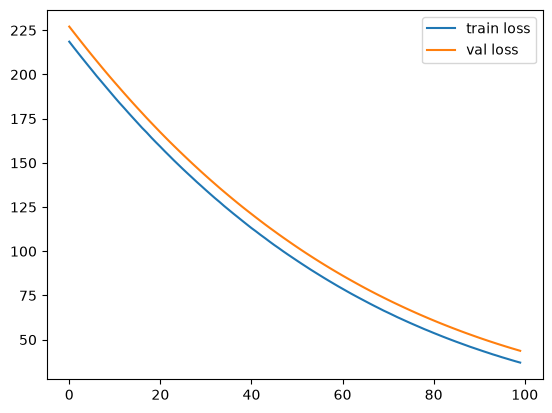

In [18]:
#plot은 cpu에서 처리됨
plt.plot(tr_loss_list, label='train loss')
plt.plot(val_loss_list, label='val loss')
plt.legend()
plt.show()


In [ ]:
# 예측
model.eval()

#미분은 gradient 계산을 위해 필요하지만, 예측에서는 필요없다. 따라서 no_grad() 를 통해 미분 계산을 하지 않도록 한다. 
with torch.no_grad():
    # pred_val = model(x_val_ts).numpy()
    pred_val = model(x_val_ts).cpu().numpy()


# true_val = y_val_ts.numpy()
true_val = y_val_ts.cpu().numpy()  #y_val_ts 는 gpu에 저장되어있기 때문에 cpu로 이동시켜야 한다.  .cpu() 를 통해 gpu에서 cpu로 이동 
# 평가
print(f'RMSE : {root_mean_squared_error(true_val, pred_val):.4f}')
print(f'MAE : {mean_absolute_error(true_val, pred_val):.4f}')
print(f'R2 : {r2_score(true_val, pred_val):.4f}')



RMSE : 14.4637
MAE : 13.2224
R2 : -4.7805
